In [1]:
!pip install ultralytics albumentations --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 92.6 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires nu

In [2]:
import os, shutil, yaml, random, cv2, torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from pathlib import Path
from ultralytics import YOLO
from PIL import Image
from tqdm.auto import tqdm
import albumentations as A

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
KAGGLE_INPUT   = "/kaggle/input/datasets/zeyadmagdinew/finaldatadetection1/Final_Dataset"   
KAGGLE_WORKING = "/kaggle/working/hiero_pro"
SLICED_DIR     = f"{KAGGLE_WORKING}/sliced_dataset"
YAML_PATH      = f"{KAGGLE_WORKING}/hiero.yaml"
RUN_DIR        = f"{KAGGLE_WORKING}/runs"

for d in [KAGGLE_WORKING, SLICED_DIR, RUN_DIR]:
    os.makedirs(d, exist_ok=True)

SLICE_SIZE  = 640      
OVERLAP     = 0.50      
STEP        = int(SLICE_SIZE * (1 - OVERLAP))  
MIN_VIS     = 0.30     
SPLITS      = ["train", "val", "test"]

print(f" Workspace: {KAGGLE_WORKING}")
print(f" tile={SLICE_SIZE}  step={STEP}  min_visibility={MIN_VIS}")
print(f" GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

✅ Workspace: /kaggle/working/hiero_pro
   tile=640  step=320  min_visibility=0.3
   GPU: Tesla T4


In [ ]:
def apply_pro_enhancement(image_bgr: np.ndarray) -> np.ndarray:
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    enhanced = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
    return cv2.filter2D(enhanced, -1, kernel)

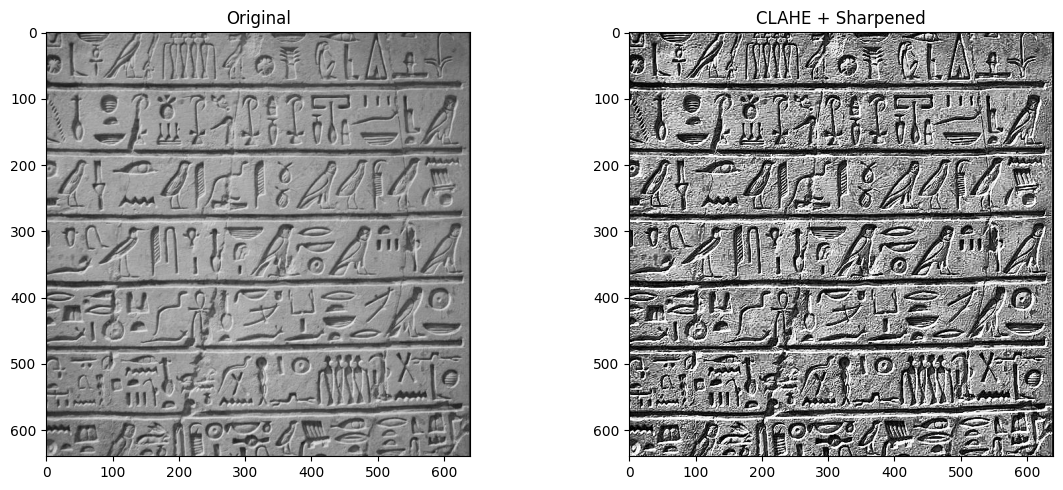

In [5]:
_test_files = list(Path(KAGGLE_INPUT).rglob("*.jpg"))[:1]
if _test_files:
    _img = cv2.imread(str(_test_files[0]))
    _enh = apply_pro_enhancement(_img)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(cv2.cvtColor(_img, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original")
    ax[1].imshow(cv2.cvtColor(_enh, cv2.COLOR_BGR2RGB)); ax[1].set_title("CLAHE + Sharpened")
    plt.tight_layout(); plt.show()

In [ ]:
def count_dataset(root: str):
    stats = {}
    for split in SPLITS:
        img_dir = Path(root) / split / "images"
        lbl_dir = Path(root) / split / "labels"
        imgs = list(img_dir.glob("*.*")) if img_dir.exists() else []
        lbls = list(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []
        box_count = sum(len(open(l).readlines()) for l in lbls)
        stats[split] = {"images": len(imgs), "labels": len(lbls), "boxes": box_count}
    df = pd.DataFrame(stats).T
    print("\n Dataset stats:\n", df.to_string())
    return df

count_dataset(KAGGLE_INPUT)


📊 Dataset stats:
        images  labels  boxes
train     226     226   6553
val        65      65   2358
test       33      33   1671


,images,labels,boxes
train,226,226,6553
val,65,65,2358
test,33,33,1671


In [ ]:
def yolo_to_pixel(label_line: str, img_w: int, img_h: int):
    parts = label_line.strip().split()
    cls = int(parts[0])
    xc, yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
    x1 = (xc - bw / 2) * img_w
    y1 = (yc - bh / 2) * img_h
    x2 = (xc + bw / 2) * img_w
    y2 = (yc + bh / 2) * img_h
    return cls, x1, y1, x2, y2


def pixel_to_yolo(cls: int, x1, y1, x2, y2, tile_w: int, tile_h: int) -> str:
    xc = ((x1 + x2) / 2) / tile_w
    yc = ((y1 + y2) / 2) / tile_h
    bw = (x2 - x1) / tile_w
    bh = (y2 - y1) / tile_h
    # Clamp to [0, 1]
    xc = max(0.0, min(1.0, xc))
    yc = max(0.0, min(1.0, yc))
    bw = max(0.0, min(1.0, bw))
    bh = max(0.0, min(1.0, bh))
    return f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}"


def slice_image_and_labels(
    img_path: Path,
    lbl_path: Path | None,
    out_img_dir: Path,
    out_lbl_dir: Path,
    slice_size: int = SLICE_SIZE,
    step: int = STEP,
    min_visibility: float = MIN_VIS,
    enhance: bool = True,
) -> int:

    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        return 0

    if enhance:
        img_bgr = apply_pro_enhancement(img_bgr)

    H, W = img_bgr.shape[:2]

    raw_labels: list[str] = []
    if lbl_path and lbl_path.exists():
        raw_labels = open(lbl_path).readlines()

    parsed_boxes: list[tuple] = []
    for line in raw_labels:
        line = line.strip()
        if not line:
            continue
        try:
            parsed_boxes.append(yolo_to_pixel(line, W, H))
        except Exception:
            pass

    y_offs = list(range(0, max(1, H - slice_size + 1), step))
    if H > slice_size and y_offs[-1] != H - slice_size:
        y_offs.append(H - slice_size)
    x_offs = list(range(0, max(1, W - slice_size + 1), step))
    if W > slice_size and x_offs[-1] != W - slice_size:
        x_offs.append(W - slice_size)

    stem = img_path.stem
    tile_count = 0

    for yi, oy in enumerate(y_offs):
        for xi, ox in enumerate(x_offs):
            tile = img_bgr[oy: oy + slice_size, ox: ox + slice_size]
            th, tw = tile.shape[:2]
            tile_labels: list[str] = []
            for cls, bx1, by1, bx2, by2 in parsed_boxes:
                tx1 = max(bx1, ox) - ox
                ty1 = max(by1, oy) - oy
                tx2 = min(bx2, ox + tw) - ox
                ty2 = min(by2, oy + th) - oy

                if tx2 <= tx1 or ty2 <= ty1:
                    continue  

                orig_area = max(1e-6, (bx2 - bx1) * (by2 - by1))
                inter_area = (tx2 - tx1) * (ty2 - ty1)
                if inter_area / orig_area < min_visibility:
                    continue

                tile_labels.append(pixel_to_yolo(cls, tx1, ty1, tx2, ty2, tw, th))

            if not tile_labels:
                continue

            tile_name = f"{stem}_t{yi:02d}_{xi:02d}"
            cv2.imwrite(str(out_img_dir / f"{tile_name}.jpg"), tile)
            with open(out_lbl_dir / f"{tile_name}.txt", "w") as f:
                f.write("\n".join(tile_labels))
            tile_count += 1

    return tile_count

In [ ]:
def process_split(split: str, enhance: bool = True):
    src_img = Path(KAGGLE_INPUT) / split / "images"
    src_lbl = Path(KAGGLE_INPUT) / split / "labels"

    dst_img = Path(SLICED_DIR) / split / "images"
    dst_lbl = Path(SLICED_DIR) / split / "labels"
    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)

    images = sorted(src_img.glob("*.*"))
    total_tiles = 0
    for img_path in tqdm(images, desc=f"Slicing {split}"):
        lbl_path = src_lbl / (img_path.stem + ".txt")
        total_tiles += slice_image_and_labels(
            img_path, lbl_path, dst_img, dst_lbl, enhance=(split != "test")
        )

    print(f"  [{split}] {len(images)} images → {total_tiles} tiles saved")
    return total_tiles


print("Slicing dataset (CLAHE + sharpening applied to train/val)...")
for split in SPLITS:
    process_split(split)

print("\n Slicing complete!")
count_dataset(SLICED_DIR)

⚙️  Slicing dataset (CLAHE + sharpening applied to train/val)...


Slicing train:   0%|          | 0/226 [00:00<?, ?it/s]

  [train] 226 images → 850 tiles saved


Slicing val:   0%|          | 0/65 [00:00<?, ?it/s]

  [val] 65 images → 276 tiles saved


Slicing test:   0%|          | 0/33 [00:00<?, ?it/s]

  [test] 33 images → 145 tiles saved

✅ Slicing complete!

📊 Dataset stats:
        images  labels  boxes
train     850     850  13267
val       276     276   5280
test      145     145   4479


,images,labels,boxes
train,850,850,13267
val,276,276,5280
test,145,145,4479


In [ ]:
aug_pipeline = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.35, p=0.8),
        A.GaussNoise(var_limit=(10, 50), p=0.4),
        A.ISONoise(p=0.3),
        A.Blur(blur_limit=3, p=0.2),
        A.MedianBlur(blur_limit=3, p=0.15),
        A.ImageCompression(quality_lower=70, quality_upper=100, p=0.3),
        A.Perspective(scale=(0.03, 0.08), p=0.3),
        A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.1, rotate_limit=8, p=0.5),
        A.RandomShadow(p=0.15),
        A.ToGray(p=0.1),   # some stone images are greyscale
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.25,
    ),
)


def augment_split(n_aug_per_image: int = 2):
    img_dir = Path(SLICED_DIR) / "train" / "images"
    lbl_dir = Path(SLICED_DIR) / "train" / "labels"

    original_tiles = sorted(img_dir.glob("*.jpg"))
    added = 0

    for img_path in tqdm(original_tiles, desc="Augmenting train tiles"):
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        bboxes, classes = [], []
        for line in open(lbl_path).readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                classes.append(int(parts[0]))
                bboxes.append([float(x) for x in parts[1:]])

        if not bboxes:
            continue

        for aug_idx in range(n_aug_per_image):
            try:
                result = aug_pipeline(
                    image=img_rgb, bboxes=bboxes, class_labels=classes
                )
                aug_img = cv2.cvtColor(result["image"], cv2.COLOR_RGB2BGR)
                aug_bboxes = result["bboxes"]
                aug_classes = result["class_labels"]

                if not aug_bboxes:
                    continue

                aug_stem = f"{img_path.stem}_aug{aug_idx}"
                cv2.imwrite(str(img_dir / f"{aug_stem}.jpg"), aug_img)
                with open(lbl_dir / f"{aug_stem}.txt", "w") as f:
                    for cls, bbox in zip(aug_classes, aug_bboxes):
                        f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
                added += 1
            except Exception as e:
                pass

    print(f" Augmentation done: +{added} tiles  (total train tiles: {len(list(img_dir.glob('*.jpg')))})")

augment_split(n_aug_per_image=2)

/tmp/ipykernel_58/2705938287.py:5: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.4),
/tmp/ipykernel_58/2705938287.py:9: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=70, quality_upper=100, p=0.3),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Augmenting train tiles:   0%|          | 0/850 [00:00<?, ?it/s]

✅ Augmentation done: +1320 tiles  (total train tiles: 2170)


In [ ]:
lbl_files = list((Path(SLICED_DIR) / "train" / "labels").glob("*.txt"))
all_classes = set()
for lf in lbl_files:
    for line in open(lf):
        parts = line.strip().split()
        if parts:
            all_classes.add(int(float(parts[0])))  

NC = 1  
CLASS_NAME = "object" 

dataset_yaml = {
    "path": SLICED_DIR,
    "train": "train/images",
    "val":   "val/images",
    "test":  "test/images",
    "nc":    NC,
    "names": {0: CLASS_NAME}, 
}
with open(YAML_PATH, "w") as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print(f" Detected raw classes in labels: {sorted(all_classes)}")
print(f" YAML saved → {YAML_PATH} | NC={NC}")
print(open(YAML_PATH).read())

📌 Detected raw classes in labels: [0]
✅ YAML saved → /kaggle/working/hiero_pro/hiero.yaml | NC=1
names:
  0: object
nc: 1
path: /kaggle/working/hiero_pro/sliced_dataset
test: test/images
train: train/images
val: val/images



In [ ]:
model = YOLO("yolo11x.pt")  

results = model.train(
    data=YAML_PATH,
    project=RUN_DIR,
    name="hiero_v1",

    epochs=200,
    patience=40,           
    imgsz=640,
    batch=16,              
    workers=4,
    seed=42,
    deterministic=True,

    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=5,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,

    box=7.5,
    cls=0.5,
    dfl=1.5,

    mosaic=1.0,
    mixup=0.15,
    copy_paste=0.3,
    degrees=6.0,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    perspective=0.0005,
    flipud=0.0,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.4,
    erasing=0.4,
    auto_augment="randaugment",

    val=True,
    save=True,
    save_period=20,        
    plots=True,
    verbose=True,

    iou=0.5,
    conf=0.001,            
    max_det=500,
)

print("\n Training complete!")
print(f"   Best weights: {RUN_DIR}/hiero_v1/weights/best.pt")

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=0.001, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/hiero_pro/hiero.yaml, degrees=6.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.5, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=500, mixup=0.15, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hiero_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True

KeyboardInterrupt: 

In [ ]:
best_weights = "/kaggle/input/models/zeyad04/detect/pytorch/default/1/best (2).pt"
model_eval = YOLO(best_weights)

metrics = model_eval.val(
    data=YAML_PATH,
    split="train",
    imgsz=640,
    conf=0.05,
    iou=0.20,
    plots=True,
    save_json=True,
    project=RUN_DIR,
    name="hiero_v1_test",
    verbose=True,
)

print("\n Train Metrics:")
print(f"   mAP50:    {metrics.box.map50:.4f}")
print(f"   mAP50-95: {metrics.box.map:.4f}")
print(f"   Precision: {metrics.box.mp:.4f}")
print(f"   Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11x summary (fused): 191 layers, 56,828,179 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2118.7±1279.4 MB/s, size: 189.5 KB)
val: Scanning /kaggle/working/hiero_pro/sliced_dataset/train/labels... 2170 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2170/2170 1.2Kit/s 1.8s0.1s
val: /kaggle/working/hiero_pro/sliced_dataset/train/images/image8_jpg.rf.8286f852ebfa8dd80e1731d4621daf33_t00_00.jpg: 1 duplicate labels removed
val: /kaggle/working/hiero_pro/sliced_dataset/train/images/image8_jpg.rf.8286f852ebfa8dd80e1731d4621daf33_t00_00_aug0.jpg: 1 duplicate labels removed
val: /kaggle/working/hiero_pro/sliced_dataset/train/images/image8_jpg.rf.8286f852ebfa8dd80e1731d4621daf33_t00_00_aug1.jpg: 1 duplicate labels removed
val: New cache created: /kaggle/working/hiero_pro/sliced_dataset/train/labels.cache
                 Class     Images  Instances      Box(P     

In [ ]:
best_weights = "/kaggle/input/models/zeyad04/detect/pytorch/default/1/best (2).pt"
model_eval = YOLO(best_weights)

metrics = model_eval.val(
    data=YAML_PATH,
    split="val",
    imgsz=640,
    conf=0.05,
    iou=0.20,
    plots=True,
    save_json=True,
    project=RUN_DIR,
    name="hiero_v1_test",
    verbose=True,
)

print("\n Val Metrics:")
print(f"   mAP50:    {metrics.box.map50:.4f}")
print(f"   mAP50-95: {metrics.box.map:.4f}")
print(f"   Precision: {metrics.box.mp:.4f}")
print(f"   Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11x summary (fused): 191 layers, 56,828,179 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2230.7±457.3 MB/s, size: 173.8 KB)
val: Scanning /kaggle/working/hiero_pro/sliced_dataset/val/labels... 276 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 276/276 1.2Kit/s 0.2s<0.0s
val: New cache created: /kaggle/working/hiero_pro/sliced_dataset/val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.1s/it 19.5s0.8ss
                   all        276       5280      0.898       0.84      0.848      0.587
Speed: 1.4ms preprocess, 64.1ms inference, 0.0ms loss, 0.8ms postprocess per image
Saving /kaggle/working/hiero_pro/runs/hiero_v1_test-2/predictions.json...
Results saved to /kaggle/working/hiero_pro/runs/hiero_v1_test-2

📈 Val Metrics:
   mAP50:    0.8477
   mAP50-95: 0.5868
   Precision:

In [ ]:
best_weights = f"{RUN_DIR}/hiero_v1/weights/best.pt"
model_eval = YOLO(best_weights)

metrics = model_eval.val(
    data=YAML_PATH,
    split="test",
    imgsz=640,
    conf=0.05,
    iou=0.20,
    plots=True,
    save_json=True,
    project=RUN_DIR,
    name="hiero_v1_test",
    verbose=True,
)

print("\n Test Metrics:")
print(f"   mAP50:    {metrics.box.map50:.4f}")
print(f"   mAP50-95: {metrics.box.map:.4f}")
print(f"   Precision: {metrics.box.mp:.4f}")
print(f"   Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11x summary (fused): 191 layers, 56,828,179 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 10.2±8.4 MB/s, size: 42.0 KB)
val: Scanning /kaggle/working/hiero_pro/sliced_dataset/test/labels... 145 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 145/145 533.7it/s 0.3s0.1s
val: New cache created: /kaggle/working/hiero_pro/sliced_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.1s/it 10.9s.1s
                   all        145       4479       0.95      0.931      0.947      0.604
Speed: 0.8ms preprocess, 68.8ms inference, 0.0ms loss, 1.3ms postprocess per image
Saving /kaggle/working/hiero_pro/runs/hiero_v1_test/predictions.json...
Results saved to /kaggle/working/hiero_pro/runs/hiero_v1_test

📈 Test Metrics:
   mAP50:    0.9467
   mAP50-95: 0.6039
   Precision: 0.9503


/tmp/ipykernel_57/2925127555.py:46: UserWarning: Glyph 127994 (\N{AMPHORA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2925127555.py:47: UserWarning: Glyph 127994 (\N{AMPHORA}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{KAGGLE_WORKING}/test_inference.png", dpi=150, bbox_inches="tight")


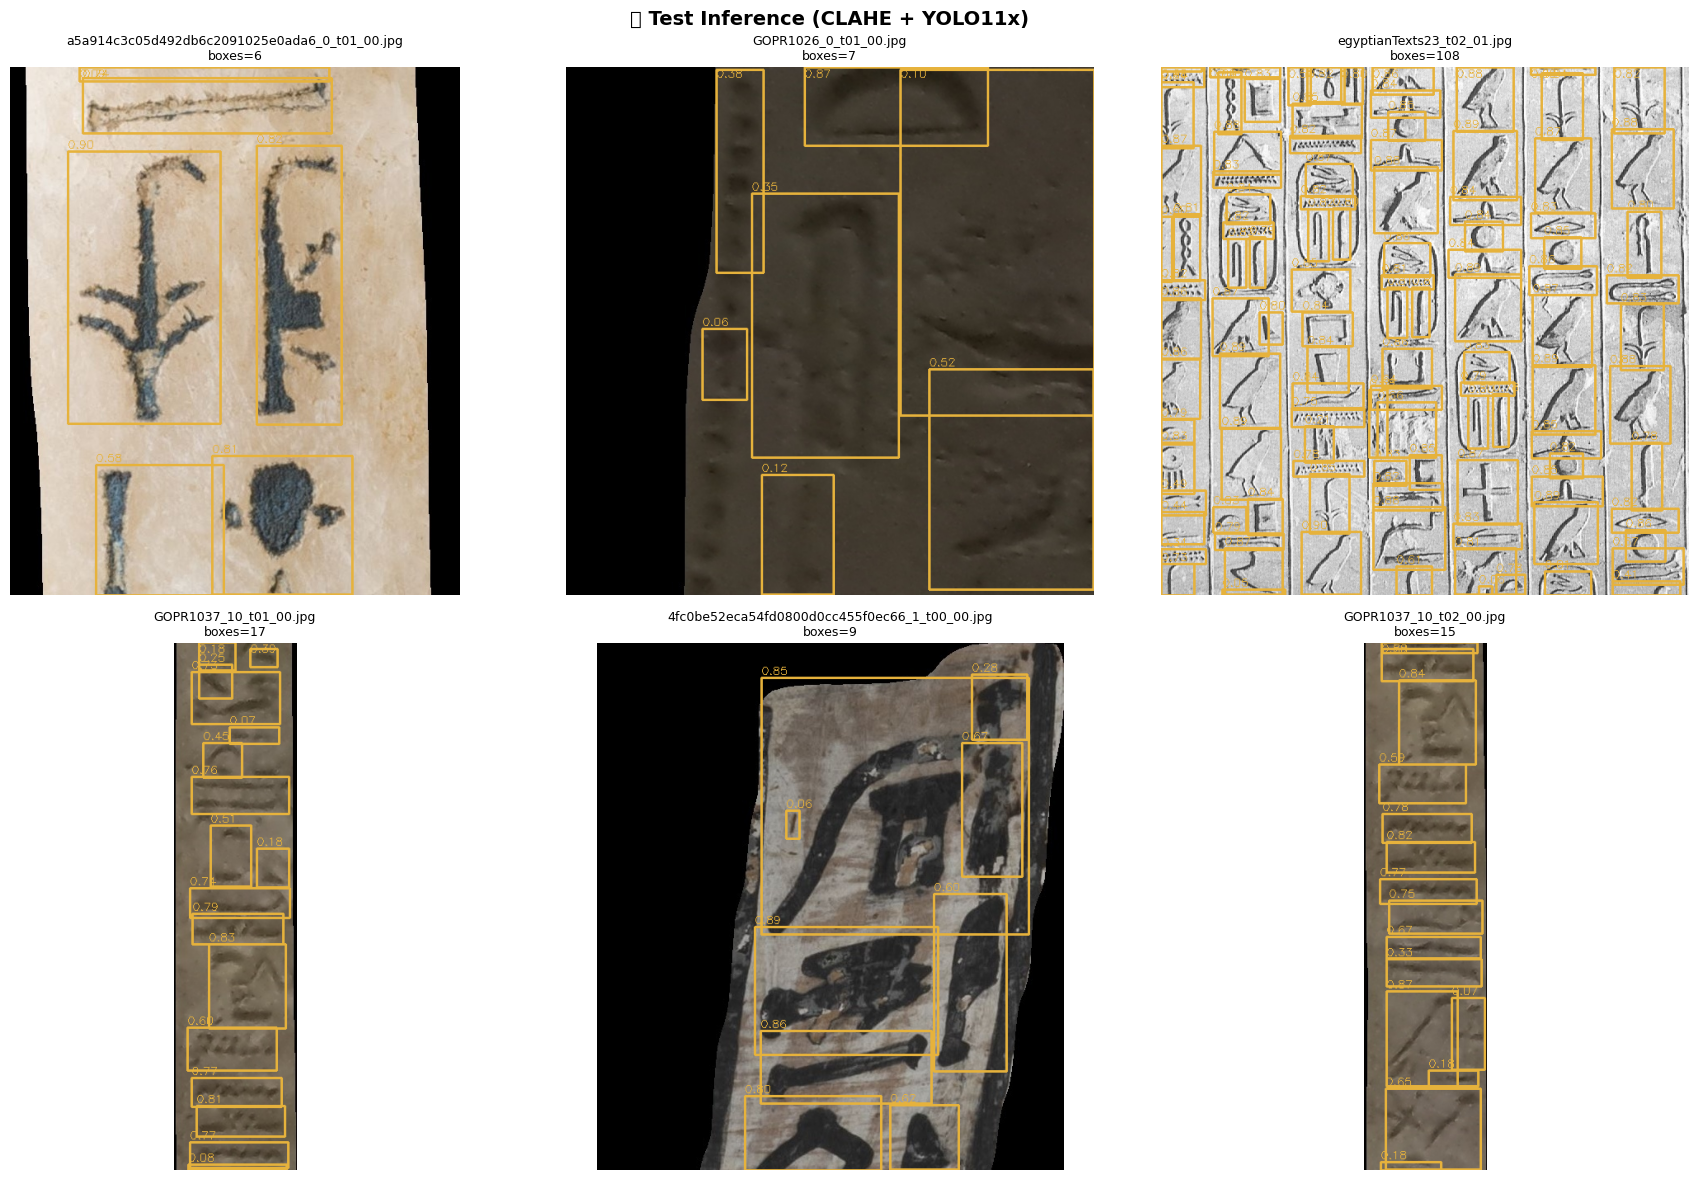

✅ Saved → /kaggle/working/hiero_pro/test_inference.png


In [ ]:
def run_inference_visual(model_path: str, img_dir: str, n_samples: int = 6,
                          conf: float = 0.05, iou: float = 0.20):
    inf_model = YOLO(model_path)
    images = sorted(Path(img_dir).glob("*.*"))
    samples = random.sample(images, min(n_samples, len(images)))

    cols = 3
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 6))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes

    for ax, img_path in zip(axes, samples):
        raw = cv2.imread(str(img_path))
        enhanced = apply_pro_enhancement(raw)

        results = inf_model.predict(
            source=[enhanced],
            conf=conf,
            iou=iou,
            imgsz=640,
            augment=False,
            verbose=False,
        )

        annotated = raw.copy()
        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
                score = float(box.conf[0])
                cv2.rectangle(annotated, (x1, y1), (x2, y2), (60, 178, 230), 2)
                cv2.putText(annotated, f"{score:.2f}", (x1, max(y1 - 4, 12)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, (60, 178, 230), 1)

        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{img_path.name}\nboxes={len(results[0].boxes)}", fontsize=9)
        ax.axis("off")

    for ax in axes[len(samples):]:
        ax.axis("off")

    plt.suptitle("🏺 Test Inference (CLAHE + YOLO11x)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{KAGGLE_WORKING}/test_inference.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f" Saved → {KAGGLE_WORKING}/test_inference.png")


run_inference_visual(
    model_path=best_weights,
    img_dir=f"{SLICED_DIR}/test/images",
    n_samples=6,
)

/tmp/ipykernel_57/3429418663.py:26: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3429418663.py:27: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{KAGGLE_WORKING}/training_curves.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


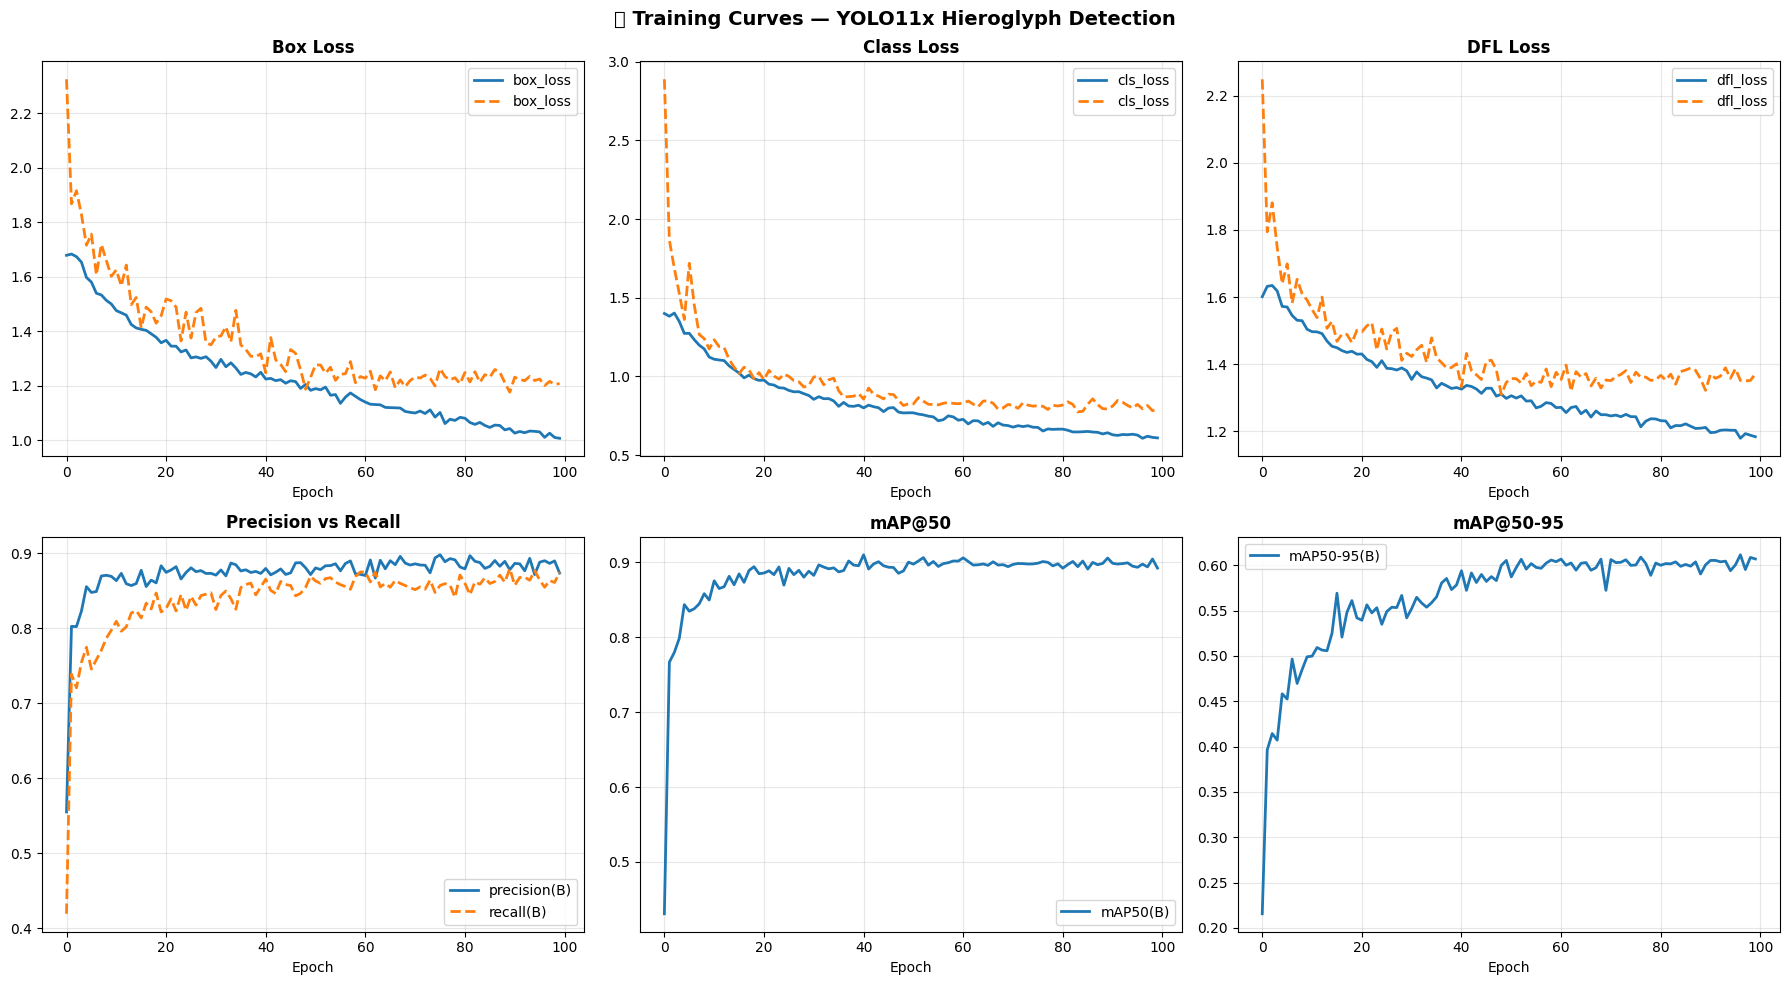

In [ ]:
results_csv = Path(f"{RUN_DIR}/hiero_v1/results.csv")
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    pairs = [
        ("train/box_loss", "val/box_loss", "Box Loss"),
        ("train/cls_loss", "val/cls_loss", "Class Loss"),
        ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
        ("metrics/precision(B)", "metrics/recall(B)", "Precision vs Recall"),
        ("metrics/mAP50(B)", None, "mAP@50"),
        ("metrics/mAP50-95(B)", None, "mAP@50-95"),
    ]
    for ax, (col1, col2, title) in zip(axes.flatten(), pairs):
        if col1 in df.columns:
            ax.plot(df[col1], label=col1.split("/")[-1], linewidth=2)
        if col2 and col2 in df.columns:
            ax.plot(df[col2], label=col2.split("/")[-1], linewidth=2, linestyle="--")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle(" Training Curves — YOLO11x Hieroglyph Detection", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{KAGGLE_WORKING}/training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


image 1/1 /kaggle/working/hiero_pro/sliced_dataset/test/images/50543a6bde034434ac90761c275a7d51_9_t00_01.jpg: 288x640 7 objects, 184.5ms
Speed: 1.0ms preprocess, 184.5ms inference, 1.4ms postprocess per image at shape (1, 3, 288, 640)

image 1/1 /kaggle/working/hiero_pro/sliced_dataset/test/images/2c259a71f96f42029b29ad508ae010f8_0_t00_07.jpg: 352x640 7 objects, 149.9ms
Speed: 1.1ms preprocess, 149.9ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /kaggle/working/hiero_pro/sliced_dataset/test/images/358808a674b04e49a32cf991d596cb94_1_t02_00.jpg: 640x384 5 objects, 143.9ms
Speed: 1.0ms preprocess, 143.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /kaggle/working/hiero_pro/sliced_dataset/test/images/2c259a71f96f42029b29ad508ae010f8_0_t00_01.jpg: 352x640 6 objects, 89.6ms
Speed: 0.9ms preprocess, 89.6ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /kaggle/working/hiero_pro/sliced_dataset/test/i

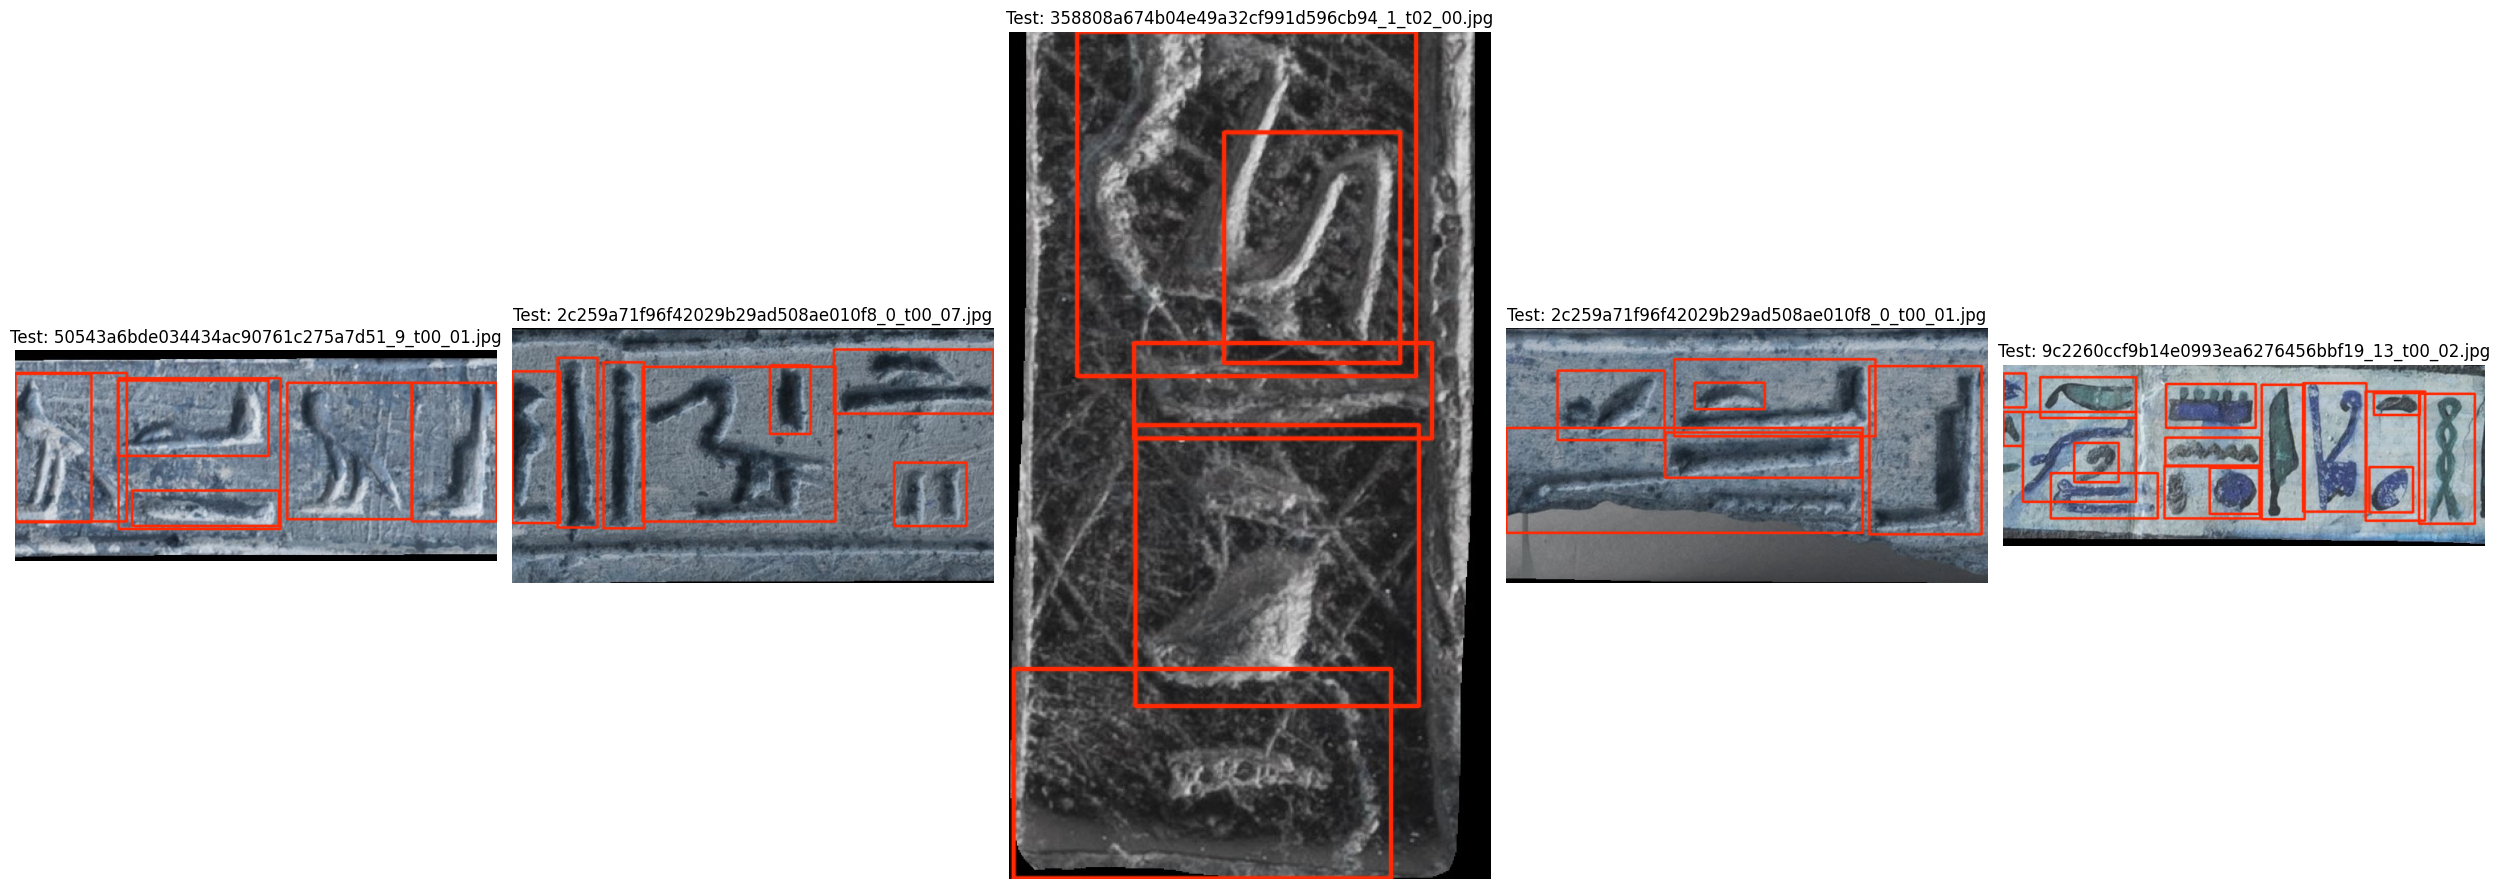

In [ ]:
best_weights = f"{RUN_DIR}/hiero_v1/weights/best.pt"
inf_model = YOLO(best_weights)
test_img_dir = f"{SLICED_DIR}/test/images"
test_imgs = [f for f in os.listdir(test_img_dir) if f.endswith('.jpg')]
if test_imgs:
    sample_test = random.sample(test_imgs, min(5, len(test_imgs)))
    fig, axes = plt.subplots(1, 5, figsize=(25, 10))
    for i, img_name in enumerate(sample_test):
        img_path = os.path.join(test_img_dir, img_name)
        res = inf_model.predict(img_path, conf=0.4, augment=True)[0]
        axes[i].imshow(res.plot(labels=False, conf=False))
        axes[i].set_title(f"Test: {img_name}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
import os
import torch
from tqdm import tqdm
from torchvision.ops import box_iou

best_weights  = f"{RUN_DIR}/hiero_v1/weights/best.pt"
test_img_dir  = f"{SLICED_DIR}/test/images"
test_lbl_dir  = f"{SLICED_DIR}/test/labels"         
test_imgs     = [f for f in os.listdir(test_img_dir) if f.endswith('.jpg')]
best_model    = YOLO(best_weights)                    

total_iou   = 0.0
match_count = 0

for img_name in tqdm(test_imgs):
    img_path = os.path.join(test_img_dir, img_name)
    lbl_path = os.path.join(                         
        test_lbl_dir,
        os.path.splitext(img_name)[0] + '.txt'
    )
    if not os.path.exists(lbl_path):
        continue

    import cv2
    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w = img.shape[:2]

    gt_boxes = []
    with open(lbl_path, 'r') as f:
        for line in f:
            _, xc, yc, bw, bh = map(float, line.split())
            xc *= w; yc *= h; bw *= w; bh *= h
            x1 = xc - bw / 2; y1 = yc - bh / 2
            x2 = xc + bw / 2; y2 = yc + bh / 2
            gt_boxes.append([x1, y1, x2, y2])
    if len(gt_boxes) == 0:
        continue
    gt_boxes = torch.tensor(gt_boxes, dtype=torch.float32)

    res = best_model.predict(img_path, conf=0.3, verbose=False)[0]
    pred_boxes = res.boxes.xyxy.cpu()
    if len(pred_boxes) == 0:
        continue

    iou_matrix = box_iou(pred_boxes, gt_boxes)

    used_gt = set()
    for p in range(iou_matrix.shape[0]):
        best_gt = torch.argmax(iou_matrix[p]).item()
        if best_gt not in used_gt:
            iou_val = iou_matrix[p, best_gt].item()
            total_iou  += iou_val
            match_count += 1
            used_gt.add(best_gt)

if match_count > 0:
    final_miou = total_iou / match_count
    print(f"\n FINAL TEST mIoU: {final_miou:.4f} ({final_miou*100:.2f}%)")

--- 📏 CALCULATING MEAN IoU (mIoU) ---


100%|██████████| 145/145 [00:09<00:00, 15.65it/s]


🏆 FINAL TEST mIoU: 0.8066 (80.66%)


In [ ]:
import os
import torch
from tqdm import tqdm
from torchvision.ops import box_iou

for split in ["train", "val", "test"]:
    img_dir = f"{SLICED_DIR}/{split}/images"
    lbl_dir = f"{SLICED_DIR}/{split}/labels"
    imgs = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]

    total_iou   = 0.0
    match_count = 0

    for img_name in tqdm(imgs, desc=f"{split.upper()}"):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + '.txt')

        if not os.path.exists(lbl_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w = img.shape[:2]
        gt_boxes = []
        with open(lbl_path, 'r') as f:
            for line in f:
                _, xc, yc, bw, bh = map(float, line.split())
                xc *= w; yc *= h; bw *= w; bh *= h
                x1 = xc - bw/2; y1 = yc - bh/2
                x2 = xc + bw/2; y2 = yc + bh/2
                gt_boxes.append([x1, y1, x2, y2])

        if len(gt_boxes) == 0:
            continue

        gt_boxes  = torch.tensor(gt_boxes, dtype=torch.float32)
        res       = model_eval.predict(img_path, conf=0.3, verbose=False)[0]
        pred_boxes = res.boxes.xyxy.cpu()

        if len(pred_boxes) == 0:
            continue

        iou_matrix = box_iou(pred_boxes, gt_boxes)
        used_gt = set()
        for p in range(iou_matrix.shape[0]):
            best_gt = torch.argmax(iou_matrix[p]).item()
            if best_gt not in used_gt:
                total_iou   += iou_matrix[p, best_gt].item()
                match_count += 1
                used_gt.add(best_gt)

    if match_count > 0:
        miou = total_iou / match_count
        print(f" {split.upper()} mIoU: {miou:.4f} ({miou*100:.2f}%)")


TRAIN: 100%|██████████| 2170/2170 [02:00<00:00, 18.01it/s]


🏆 TRAIN mIoU: 0.8748 (87.48%)


VAL: 100%|██████████| 276/276 [00:16<00:00, 16.51it/s]


🏆 VAL mIoU: 0.8192 (81.92%)


TEST: 100%|██████████| 145/145 [00:07<00:00, 18.26it/s]

🏆 TEST mIoU: 0.8066 (80.66%)


In [ ]:
import shutil

output_dir = Path("/kaggle/working")
shutil.copy(best_weights, output_dir / "hieroglyph_detection_v2.pt")
print(f" Model saved → /kaggle/working/hieroglyph_detection_v2.pt")
print(f" File size: {(output_dir / 'hieroglyph_detection_v2.pt').stat().st_size / 1e6:.1f} MB")

✅ Model saved → /kaggle/working/hieroglyph_detection_v2.pt
   File size: 456.1 MB


In [ ]:
from IPython.display import FileLink
display(FileLink('/kaggle/working/hieroglyph_detection_v2.pt'))

/kaggle/working/hieroglyph_detection_v2.pt